<a href="https://colab.research.google.com/github/PhilipPersukevic/lecture-assistant/blob/main/lecture_assistant.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎓 Paskaitų asistentas

Generatyvinio DI sistema, kuri iš paskaitos garso įrašo sukuria transkripciją (Whisper), santrauką, pagrindines sąvokas ir savitikros klausimus (Gemini API).

**Procesas:** paskaitos tekstas → garso įrašas (Gemini TTS) → transkripcija (Whisper) → analizė (Gemini) → rezultatai ir grafikas → JSON failas

**Pastaba:** demonstracijai paskaitos įrašas sugeneruotas dirbtinai iš `data/lecture1_input.txt`. Sistema veikia taip pat su bet kokiu kitu garso ar vaizdo įrašu.

## 🔗 Paruošimas
Įdiegiamos bibliotekos (`google-genai`, `openai-whisper`) ir nustatomas Gemini API raktas iš Colab Secrets.

In [6]:
#@title 🔗 SETUP: Install Dependencies and Configure API
!pip install -U -q google-genai openai-whisper

import os
from google.colab import userdata

os.environ["GEMINI_API_KEY"] = userdata.get("GOOGLE_API_KEY")
print("✅ API raktas nustatytas")

✅ API raktas nustatytas


## 🔊 STEP 1: Garso įrašo sukūrimas
Kad nereikėtų ieškoti paskaitos įrašo, paskaitos tekstas paverčiamas kalba per Gemini TTS ir išsaugomas kaip `lecture1.wav`. Tai imituoja įvesties duomenis (X).

In [7]:
#@title 🔊 STEP 1: Generate Lecture Audio from Text (Gemini TTS)
import wave
from google import genai
from google.genai import types

client = genai.Client()

lecture_text = """Neuroniniai tinklai yra mašininio mokymosi modeliai, įkvėpti žmogaus smegenų. Juos sudaro sluoksniai dirbtinių neuronų: įvesties, paslėptieji ir išvesties sluoksniai. Kiekvienas neuronas gauna skaičius, sudaugina juos iš svorių, sudeda ir perduoda per aktyvacijos funkciją, pavyzdžiui, ReLU arba sigmoid. Mokymosi metu tinklas palygina savo prognozę su tikra reikšme ir apskaičiuoja klaidą, vadinamą nuostoliu. Naudodamas atgalinį sklidimą, tinklas pakoreguoja svorius, kad klaida mažėtų. Šis procesas kartojamas daug kartų per epochas. Per didelis mokymasis gali sukelti persimokymą, kai modelis gerai veikia su mokymo duomenimis, bet prastai su naujais. Su tuo kovojama naudojant validacijos duomenis ir reguliarizaciją."""

response = client.models.generate_content(
    model="gemini-2.5-flash-preview-tts",
    contents=lecture_text,
    config=types.GenerateContentConfig(
        response_modalities=["AUDIO"],
        speech_config=types.SpeechConfig(
            voice_config=types.VoiceConfig(
                prebuilt_voice_config=types.PrebuiltVoiceConfig(voice_name="Kore")
            )
        ),
    ),
)

pcm = response.candidates[0].content.parts[0].inline_data.data
media_path = "lecture1.wav"
with wave.open(media_path, "wb") as wf:
    wf.setnchannels(1)
    wf.setsampwidth(2)
    wf.setframerate(24000)
    wf.writeframes(pcm)

print("✅ Garso failas sukurtas:", media_path)

✅ Garso failas sukurtas: lecture1.wav


## 👂 STEP 2: Transkripcija
Whisper paverčia garsą tekstu. Naudojamas `medium` modelis, nes jis tiksliau atpažįsta lietuvių kalbą. Nedidelės atpažinimo klaidos yra normalu, jas ištaiso Gemini kitame žingsnyje.

In [8]:
#@title 👂 STEP 2: Transcribe with Whisper
import whisper

model = whisper.load_model("medium")  # tiksliau lietuvių kalbai nei "small"
result = model.transcribe(
    media_path,
    language="lt",
    condition_on_previous_text=False,  # sumažina pasikartojimus
)
transcript = result["text"]

print(transcript)

 Neuroniniai tinklai yra mašininio mokymosi modeliai įkvėpti žmogaus megenų. Juos sudaro sloksnei į dirbtinių neuronų – įvesties, paslieptieji ir išvesties sloksnei. Kiekvienas neuronas gaunas skaičius, sudaugina juos išsvorių, sudeda ir perdoda per aktivacijos funkcija, pavyzdžiui, relių arba sigmoid. Mokymosi metu tinklas palygina savo prognoze su tikrą reikšmę, ir apskaičioja klaidą, vadinama nuostolių. Naudodamas atgalinis klidimą, tinklas pakoreguoja svorius, kad klaidama žėtų. Šis procesas kartojamas daug kartum per epochas. Per didelis mokymasis gali sukelti persimokymą, kai modelis gerai veikia su mokymo domenimis, met prastais su naujais. Su tuo kovojama naudojant validacijos domenis ir regularizacija.


## 🤖 STEP 3: Gemini analizė
Transkripcija siunčiama Gemini API su promptu, kuris prašo JSON formato: santraukos, pagrindinių sąvokų ir savitikros klausimų. Pridėti automatiniai pakartojimai, jei serveris laikinai perkrautas.

In [11]:
#@title 🤖 STEP 3: Generate Summary, Concepts and Questions with Gemini
import json, time
from google import genai
from google.genai import types

client = genai.Client()
MODEL = "gemini-3.8-flash"

prompt = f"""Tu esi paskaitų asistentas. Žemiau pateikta paskaitos transkripcija (gali turėti nedidelių atpažinimo klaidų, ištaisyk jas pagal kontekstą). Sugeneruok:
1. trumpą santrauką (2 sakiniai),
2. 4-5 pagrindines sąvokas,
3. 4 savitikros klausimus.

Atsakyk TIK JSON formatu, lietuvių kalba:
{{
  "santrauka": "...",
  "pagrindines_savokos": ["...", "..."],
  "savitikros_klausimai": ["...", "..."]
}}

Transkripcija:
{transcript}
"""

data = None
for attempt in range(1, 6):
    try:
        response = client.models.generate_content(
            model=MODEL,
            contents=prompt,
            config=types.GenerateContentConfig(response_mime_type="application/json"),
        )
        data = json.loads(response.text)
        break
    except Exception as e:
        print(f"Bandymas {attempt} nepavyko: {str(e)[:80]}")
        time.sleep(10 * attempt)

if data:
    print("✅ Gemini atsakymas gautas")
    print(json.dumps(data, ensure_ascii=False, indent=2))
else:
    print("❌ Nepavyko, pabandyk vėliau")

Bandymas 1 nepavyko: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently exp
Bandymas 2 nepavyko: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently exp
Bandymas 3 nepavyko: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently exp
Bandymas 4 nepavyko: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently exp
✅ Gemini atsakymas gautas
{
  "santrauka": "Neuroniniai tinklai yra žmogaus smegenų veikla paremti mašininio mokymosi modeliai, sudaryti iš sluoksnių, kuriuose duomenys apdorojami naudojant svorius ir aktyvacijos funkcijas. Mokymosi proceso metu tinklas atgalinio klaidos sklidimo metodu optimizuoja svorius, o siekiant išvengti persimokymo taikoma regularizacija ir validacijos duomenys.",
  "pagrindines_savokos": [
    "Neuronų sluoksniai (įvesties, paslėptieji, išvesties)",
    "Aktyvacijos funkcija (ReLU, sigmoidė)",
    "Nuostolis (klaida)",
    "Atgalinis klaidos sklidimas",
    "Pe

## 📊 STEP 4: Rezultatai
JSON atsakymas parodomas skaitomu pavidalu.

In [12]:
#@title 📊 STEP 4: Display Results
from IPython.display import display, Markdown

display(Markdown(f"### 📝 Santrauka\n{data['santrauka']}"))
display(Markdown("### 🔑 Pagrindinės sąvokos\n" + "\n".join(f"- {s}" for s in data["pagrindines_savokos"])))
display(Markdown("### ❓ Savitikros klausimai\n" + "\n".join(f"{i}. {q}" for i, q in enumerate(data["savitikros_klausimai"], 1))))

### 📝 Santrauka
Neuroniniai tinklai yra žmogaus smegenų veikla paremti mašininio mokymosi modeliai, sudaryti iš sluoksnių, kuriuose duomenys apdorojami naudojant svorius ir aktyvacijos funkcijas. Mokymosi proceso metu tinklas atgalinio klaidos sklidimo metodu optimizuoja svorius, o siekiant išvengti persimokymo taikoma regularizacija ir validacijos duomenys.

### 🔑 Pagrindinės sąvokos
- Neuronų sluoksniai (įvesties, paslėptieji, išvesties)
- Aktyvacijos funkcija (ReLU, sigmoidė)
- Nuostolis (klaida)
- Atgalinis klaidos sklidimas
- Persimokymas ir regularizacija

### ❓ Savitikros klausimai
1. Iš kokių trijų pagrindinių sluoksnių tipų susideda dirbtinis neuroninis tinklas?
2. Kokią funkciją neurone atlieka svoriai ir aktyvacijos funkcijos?
3. Kaip veikia atgalinis klaidos sklidimas ir kam jis reikalingas mokymosi metu?
4. Kas yra modelio persimokymas ir kokios priemonės padeda jo išvengti?

## 📈 STEP 5: Vizualizacija
Grafikas rodo dažniausius paskaitos žodžius, tai padeda greitai pamatyti pagrindines temas.

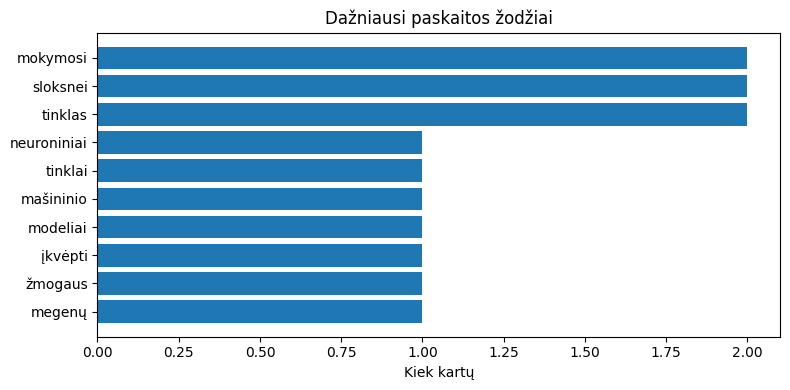

In [13]:
#@title 📈 STEP 5: Visualize Most Frequent Words
import re
from collections import Counter
import matplotlib.pyplot as plt

words = [w for w in re.findall(r"\w+", transcript.lower()) if len(w) > 4]
top = Counter(words).most_common(10)

plt.figure(figsize=(8, 4))
plt.barh([w for w, _ in top][::-1], [c for _, c in top][::-1])
plt.title("Dažniausi paskaitos žodžiai")
plt.xlabel("Kiek kartų")
plt.tight_layout()
plt.show()

## 💾 STEP 6: Išsaugojimas
Rezultatai išsaugomi kaip `lecture_output.json` (y) ir `lecture_transcript.txt`.

In [14]:
#@title 💾 STEP 6: Save Results
import json
from google.colab import files

with open("lecture_output.json", "w", encoding="utf-8") as f:
    json.dump(data, f, ensure_ascii=False, indent=2)
with open("lecture_transcript.txt", "w", encoding="utf-8") as f:
    f.write(transcript)

files.download("lecture_output.json")
print("✅ Rezultatai išsaugoti")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Rezultatai išsaugoti
